In [4]:
# Import required libraries and packages
import sys
sys.path.insert(1, "/mnt/c/Users/PC/Desktop/wikolego-repository/ai-path/ml-next-step/src")

import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

import config

print(tf.__version__)

2.10.0


In [5]:
# Load MNIST data
dataframe = pd.read_csv(config.NEW_DATA_PATH)

# initialize training data
df = dataframe.drop(columns=["id"])

df_train = df.loc[df["kfold"] != 1, :]
df_test = df.loc[df["kfold"] == 1, :]

df_train = df_train.drop(columns=["kfold"])
df_test = df_test.drop(columns=["kfold"])

X_data = df_train.drop(columns=["label"]).values
y_data = df_train.loc[:, "label"].values

print(len(X_data[1]))
# X_data
print(len(y_data))
y_data
# df_test

784
8000


array([6, 6, 5, ..., 3, 8, 4])

Epoch 1/500
250/250 [==============================] - 1s 1ms/step - loss: 8.2005 - sparse_categorical_accuracy: 0.3035
Epoch 2/500
250/250 [==============================] - 0s 1ms/step - loss: 1.8141 - sparse_categorical_accuracy: 0.3806
Epoch 3/500
250/250 [==============================] - 0s 1ms/step - loss: 1.6240 - sparse_categorical_accuracy: 0.4325
Epoch 4/500
250/250 [==============================] - 0s 1ms/step - loss: 1.4494 - sparse_categorical_accuracy: 0.4805
Epoch 5/500
250/250 [==============================] - 0s 1ms/step - loss: 1.3441 - sparse_categorical_accuracy: 0.5476
Epoch 6/500
250/250 [==============================] - 0s 1ms/step - loss: 1.2737 - sparse_categorical_accuracy: 0.5565
Epoch 7/500
250/250 [==============================] - 0s 1ms/step - loss: 1.1896 - sparse_categorical_accuracy: 0.5918
Epoch 8/500
250/250 [==============================] - 0s 2ms/step - loss: 1.1143 - sparse_categorical_accuracy: 0.6108
Epoch 9/500
250/250 [===================

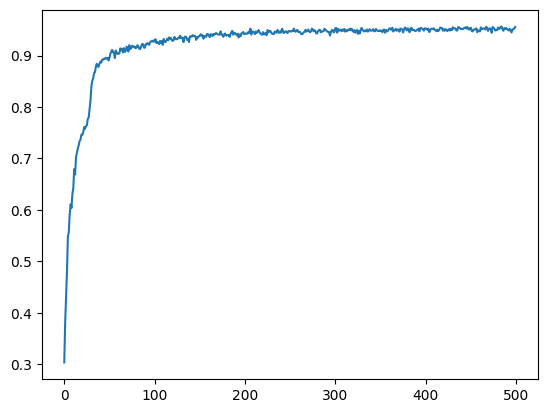

In [15]:

# Initialize model
# model = tf.keras.models.Sequential([
#     tf.keras.layers.Dense(28 * 28), # input layer
#     tf.keras.layers.Dense(64, activation="relu"),
#     tf.keras.layers.Dense(64, activation="relu"),
#     tf.keras.layers.Dense(10) # output layer
# ])

model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(len(X_data[1]), )), # input layer
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax") # output layer
])

# Compile model
model.compile(
    optimizer="Adam",
    loss="SparseCategoricalCrossentropy",
    metrics=["SparseCategoricalAccuracy"]
)

# X_data = df_train.drop(columns=["label"])

# print(len(X_data.columns))

# exit()

# Fit model
result = model.fit(
    df_train.drop(columns=["label"]).values,
    df_train.loc[:, "label"].values,
    epochs=500
)

# Predict and print predictions
predictions = max(result.history["sparse_categorical_accuracy"])
print(predictions)

if True:
    # plt.subplot()
    plt.plot(result.history["sparse_categorical_accuracy"])
    # plt.plot(result.history["loss"])
    plt.show()

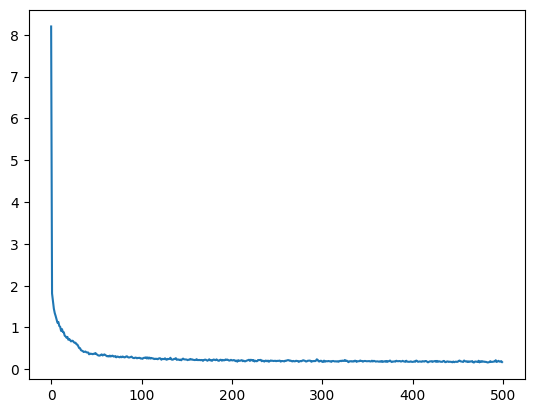

In [16]:
plt.plot(result.history["loss"])
plt.show()